In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)#tutarlı random sayı oluşturuyor

set1no= 900
set2no= 100

In [3]:
df1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=set1no),#np.random.normal=normal dağılıma göre oluştursun
    'feature_2': np.random.normal(loc=0, scale=1, size=set1no),#loc=ortalama,scale=standart sapma
    'target': [0] * set1no
})

df2 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=set2no),
    'feature_2': np.random.normal(loc=2, scale=1, size=set2no),
    'target': [1] * set2no
})

In [5]:
df1.head()

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0


In [6]:
df2.head()

,feature_1,feature_2,target
0,3.901191,2.696954,1
1,1.939339,1.666181,1
2,1.291593,3.173125,1
3,0.486286,2.369642,1
4,0.196860,1.892698,1


In [7]:
df=pd.concat([df1,df2]).reset_index(drop=True)

In [8]:
df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,1.629989,3.070150,1
996,1.741204,1.973479,1
997,3.598647,1.118125,1
998,2.560919,1.836933,1


In [9]:
df['target'].unique()

array([0, 1])

In [10]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [11]:
#upsampling = birleri,azınlık olanları artırmak

In [13]:
#downsampling = çoğunluğu azaltmak ya 0ları 100e ya da 1leri 900e #her zaman tercih edilmeyebilir çünkü datayı düşürüyor

In [14]:
#upsampling

In [15]:
df_minority=df[df['target']==1]

In [16]:
df_minority

,feature_1,feature_2,target
900,3.901191,2.696954,1
901,1.939339,1.666181,1
902,1.291593,3.173125,1
903,0.486286,2.369642,1
904,0.196860,1.892698,1
...,...,...,...
995,1.629989,3.070150,1
996,1.741204,1.973479,1
997,3.598647,1.118125,1
998,2.560919,1.836933,1


In [17]:
df_majority=df[df['target']==0]

In [18]:
df_majority

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
895,0.648710,-0.751969,0
896,-0.167118,-0.319054,0
897,0.146714,-0.796026,0
898,1.206509,1.076007,0


In [19]:
from sklearn.utils import resample

In [21]:
df_minority_upsampled =resample(df_minority , replace=True , n_samples=len(df_majority) , random_state=42)

In [22]:
df_minority_upsampled

,feature_1,feature_2,target
951,3.775311,3.261922,1
992,1.563614,3.188913,1
914,1.731469,0.198942,1
971,1.785079,-0.940389,1
960,1.865691,1.945106,1
...,...,...,...
952,0.806363,1.094268,1
965,0.337508,2.089581,1
976,1.437832,3.124113,1
942,1.451275,2.269127,1


In [23]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [24]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


In [26]:
df_majority_downsampled =resample(df_majority , replace=True , n_samples=len(df_minority) , random_state=42)

In [27]:
df_majority_downsampled

,feature_1,feature_2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
201,0.560785,-2.896255,0
269,0.130741,0.853416,0
862,1.547505,0.075434,0
815,-1.485560,-0.090533,0


In [28]:
df_downsampled=pd.concat([df_majority_downsampled,df_minority])

In [29]:
df_downsampled

,feature_1,feature_2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
995,1.629989,3.070150,1
996,1.741204,1.973479,1
997,3.598647,1.118125,1
998,2.560919,1.836933,1


In [30]:
df_downsampled['target'].value_counts()

,count
target,
0,100
1,100


In [31]:
#SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic instances of the minority class by interpolating between existing instances. Azınlığı çogaltma

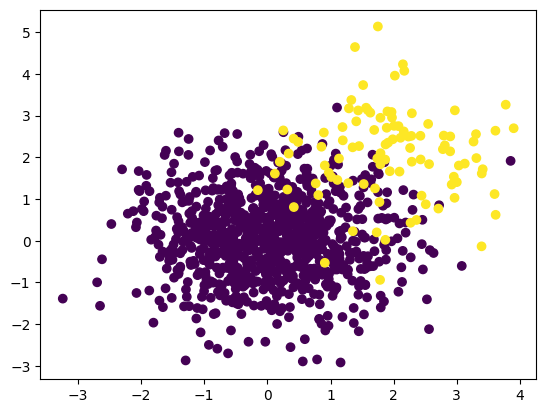

In [32]:
import matplotlib.pyplot as plt
plt.scatter(df['feature_1'],df['feature_2'],c=df['target'])

In [33]:
from imblearn.over_sampling import SMOTE

In [36]:
oversample = SMOTE()
(X,y)=oversample.fit_resample(df[['feature_1','feature_2']],df['target'])

In [38]:
X

,feature_1,feature_2
0,0.496714,0.368673
1,-0.138264,-0.393339
2,0.647689,0.028745
3,1.523030,1.278452
4,-0.234153,0.191099
...,...,...
1795,1.922796,1.872630
1796,1.131954,1.500400
1797,1.649875,0.204997
1798,2.556543,1.840588


In [39]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1795,1
1796,1
1797,1
1798,1


In [41]:
df1=pd.DataFrame(X,columns=['feature_1','feature_2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)


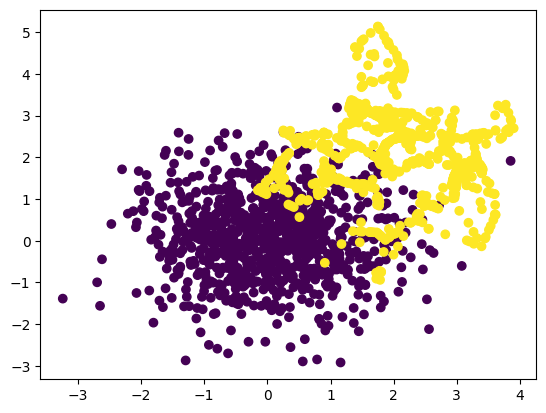

In [42]:
plt.scatter(oversample_df['feature_1'],oversample_df['feature_2'],c=oversample_df['target'])